Proyecto de la universidad.


___
### **Sesión 11**
## Aprendizaje Automático en Procesamiento de Imágenes

___

### Objetivos
- Comprender la **relevancia del aprendizaje automático** en el procesamiento de imágenes.
- Aplicar **técnicas de correlación** para la detección de patrones y características en imágenes.
- Implementar y evaluar métodos de **aprendizaje no supervisado**, como PCA y clustering, para analizar y agrupar datos de imágenes.
- Utilizar algoritmos de **aprendizaje supervisado** para la clasificación y mejora de la resolución de imágenes.

### Contenidos
- [Revisión de Conceptos](#conceptos12)
- [Búsqueda de Patrones por Correlación](#correlacion12)
- [Aprendizaje No Supervisado](#nosupervisado12)
- [Aprendizaje Supervisado](#supervisado12)
- [Ejercicios de práctica](#ejercicios12)


<div style="page-break-before: always;"></div>

___
 <a class='anchor' id='conceptos12'></a>
 
## Revisión de Conceptos

<div style="display:flex; justify-content:space-around; align-items:center;">
    <img src="images/ai_ml_dl.png" style="width:35%; height:auto;">
</div>
<p style="text-align: center;">Inteligencia Artificial vs. Aprendizaje Automático vs. Aprendizaje Profundo</p>
<br>

### *Configuración del Entorno*

En esta práctica, utilizaremos algunas bibliotecas especializadas en aprendizaje automático y manejo de datos que no hemos necesitado hasta ahora. Si aún no las tienes instaladas en tu entorno de ejecución, ejecuta el siguiente comando:

```bash
micromamba install --name prim --channel conda-forge scikit-learn tensorflow keras pandas
```


<div style="page-break-before: always;"></div>

___
 <a class='anchor' id='correlacion12'></a>

## Búsqueda de Patrones por Correlación

La búsqueda de patrones por correlación ([template matching](https://en.wikipedia.org/wiki/Template_matching)) es una técnica muy utilizada en el procesamiento de imágenes y visión por computadora, que se utiliza para identificar y localizar patrones o características específicas dentro de una imagen. Esta técnica consiste en comparar una plantilla (un patrón de referencia) con diferentes secciones de una imagen más grande para encontrar las coincidencias más fuertes. La correlación evalúa la similitud entre la plantilla y las regiones de la imagen, generando un mapa de correlación donde los picos indican áreas de alta similitud. El siguiente bloque de código muestra su implementación.

Tiempo de ejecución: 53.37 segundos


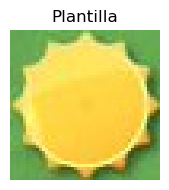

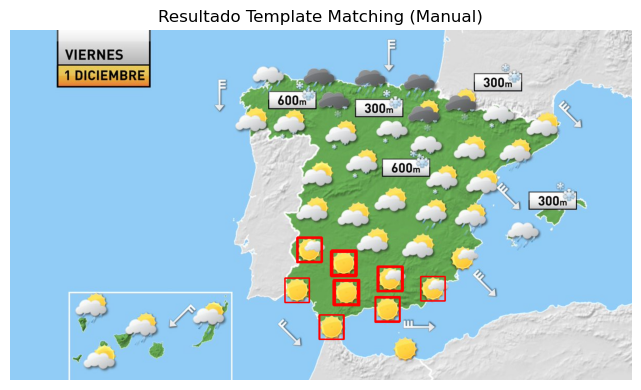

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time

def normalized_cross_correlation(image, template):
    """
    Realiza la coincidencia de plantillas usando la correlación cruzada normalizada.
    """
    # Obtener dimensiones de la imagen y la plantilla
    image_h, image_w = image.shape
    template_h, template_w = template.shape
    
    # Inicializar el resultado
    result = np.zeros((image_h - template_h + 1, image_w - template_w + 1))

    # Realizar la correlación cruzada normalizada manualmente
    for y in range(image_h - template_h + 1):
        for x in range(image_w - template_w + 1):
            # Extraer la región de interés de la imagen
            roi = image[y:y + template_h, x:x + template_w]
            # Calcular la media de la ROI y la plantilla
            mean_roi = np.mean(roi)
            mean_template = np.mean(template)
            # Calcular la desviación estándar de la ROI y la plantilla
            std_roi = np.std(roi)
            std_template = np.std(template)
            # Evitar división por cero
            if std_roi == 0 or std_template == 0:
                result[y, x] = 0
            else:
                # Calcular la correlación cruzada normalizada
                ncc = np.sum((roi - mean_roi) * (template - mean_template)) / (std_roi * std_template * template.size)
                result[y, x] = ncc

    return result

# Cargar la imagen principal y la plantilla
image = cv2.imread('./images/mapa.jpg')
template = cv2.imread('./images/sol.jpg')

# Convertimos a RGB para visualizar con matplotlib
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
template_rgb = cv2.cvtColor(template, cv2.COLOR_BGR2RGB)

# Convertir las imágenes a escala de grises
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
template_gray = cv2.cvtColor(template, cv2.COLOR_BGR2GRAY)

# Aplicar el método de coincidencia de plantillas manualmente
time_start = time.time()
result = normalized_cross_correlation(image_gray, template_gray)
time_end = time.time()
print('Tiempo de ejecución: {:.2f} segundos'.format(time_end - time_start))

# Definir un umbral para considerar una coincidencia
threshold = 0.75
locations = np.where(result >= threshold)

# Obtener las dimensiones de la plantilla
w, h = template.shape[0:2]

# Copiar la imagen RGB para dibujar los rectángulos
image_rgb1 = image_rgb.copy()

# Dibujar rectángulos alrededor de todas las coincidencias
for pt in zip(*locations[::-1]):
    top_left = pt
    bottom_right = (top_left[0] + w, top_left[1] + h)
    cv2.rectangle(image_rgb1, top_left, bottom_right, (255, 0, 0), 2)

# Mostrar la imagen de la plantilla
plt.figure(figsize=(2, 2))
plt.imshow(template_rgb); plt.title('Plantilla'); plt.axis('off')
plt.tight_layout()
plt.show()

# Mostrar la imagen resultante con las coincidencias marcadas
plt.figure(figsize=(8, 4))
plt.imshow(image_rgb1); plt.title('Resultado Template Matching (Manual)'); plt.axis('off')
plt.tight_layout()
plt.show()

La función `normalized_cross_correlation` calcula la correlación entre la plantilla y todas las regiones de la imagen, obteniendo un mapa de similitud que se utiliza para detectar coincidencias al superar un umbral predefinido. Como podemos observar, el resultado obtenido no es perfecto, presentando falsos positivos y negativos, además de múltiples detecciones muy cercanas para una misma coincidencia debido al margen establecido por el umbral. El coste computacional de utilizar un doble bucle para el cálculo del mapa de correlación es también muy elevado. Afortunadamente, *OpenCV* implementa estas operaciones de forma mucho más eficiente y ofrece una función de supresión de no máximos para eliminar detecciones redundantes.

Tiempo de ejecución: 0.03 segundos


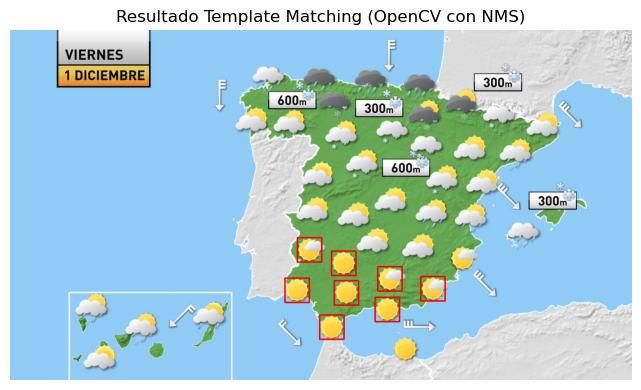

In [2]:
# Copiar la imagen original
image_rgb2 = image_rgb.copy()

# Aplicar el método de coincidencia de plantillas de OpenCV
time_start2 = time.time()
result2 = cv2.matchTemplate(image_gray, template_gray, cv2.TM_CCOEFF_NORMED)
time_end2 = time.time()
print('Tiempo de ejecución: {:.2f} segundos'.format(time_end2 - time_start2))

# Buscar coincidencias con el umbral definido anteriormente
locations2 = np.where(result2 >= threshold)

# Crear una lista de las cajas delimitadoras y sus scores
boxes = []
scores = []
for pt in zip(*locations2[::-1]):
    top_left = pt
    bottom_right = (top_left[0] + w, top_left[1] + h)
    boxes.append([top_left[0], top_left[1], bottom_right[0] - top_left[0], bottom_right[1] - top_left[1]])
    scores.append(result2[pt[1], pt[0]])

# Aplicar la supresión de no máximos
indices = cv2.dnn.NMSBoxes(boxes, scores, score_threshold=threshold, nms_threshold=0.3)

# Dibujar rectángulos alrededor de las coincidencias después de la supresión de no máximos
for i in indices:
    box = boxes[i]
    top_left = (box[0], box[1])
    bottom_right = (box[0] + box[2], box[1] + box[3])
    cv2.rectangle(image_rgb2, top_left, bottom_right, (255, 0, 0), 2)

# Mostrar la imagen resultante con las coincidencias marcadas
plt.figure(figsize=(8, 4))
plt.imshow(image_rgb2)
plt.title('Resultado Template Matching (OpenCV con NMS)')
plt.axis('off')
plt.tight_layout()
plt.show()

<div style="page-break-before: always;"></div>

___
 <a class='anchor' id='nosupervisado12'></a>
 
## Aprendizaje No Supervisado

El [aprendizaje no supervisado](https://en.wikipedia.org/wiki/Supervised_learning) es una metodología fundamental en el procesamiento de imágenes ya que permite descubrir patrones y estructuras ocultas en los datos sin la necesidad de etiquetas predefinidas. En las próximas secciones, se explorarán dos métodos muy importantes: el Análisis de Componentes Principales (PCA) y el agrupamiento (clustering).

### Análisis de Componentes Principales (PCA)

El Análisis de Componentes Principales ([PCA](https://en.wikipedia.org/wiki/Principal_component_analysis)) es una técnica de reducción de dimensionalidad utilizada para identificar las características más importantes en un conjunto de datos, como imágenes, al transformar los datos originales en un nuevo conjunto de variables ortogonales llamadas componentes principales. Estas componentes capturan la mayor cantidad de variabilidad presente en los datos, permitiendo representar la información con menos dimensiones sin perder las características esenciales. A continuación, veremos un ejemplo de su uso.

Forma de los datos: (1797, 64)


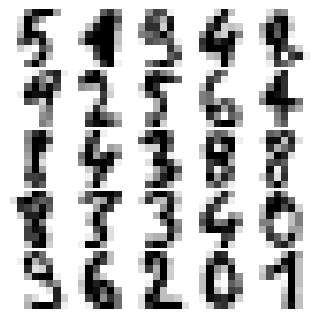

Varianza explicada acumulada: 0.29


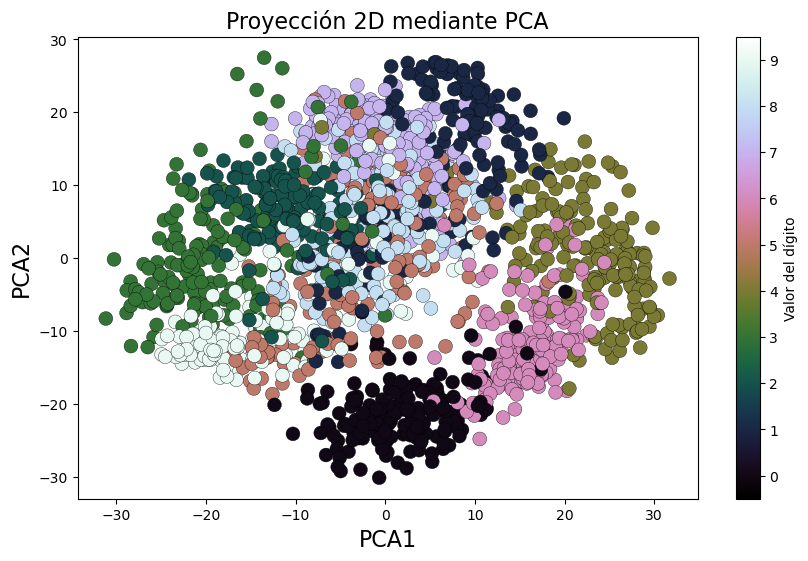

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Cargar el conjunto de datos de dígitos
digits = load_digits()

# Imprimir la forma de los datos
print("Forma de los datos:", digits.data.shape)

# Establecer una semilla para la reproducibilidad
np.random.seed(1)

# Crear una figura para visualizar algunas imágenes de dígitos
fig = plt.figure(figsize=(3, 3))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)

# Seleccionar 25 imágenes aleatorias y mostrarlas
for i, idx in enumerate(np.random.choice(digits.data.shape[0], 25), start=1):
    ax = fig.add_subplot(5, 5, i)
    ax.imshow(np.reshape(digits.data[idx, :], (8, 8)), cmap='binary')
    ax.axis('off')
plt.show()

# Aplicar PCA para reducir la dimensionalidad a 2 componentes principales
pca_digits = PCA(n_components=2)
data_proj = pca_digits.fit_transform(digits.data)

# Imprimir la suma de la varianza explicada
print(f"Varianza explicada acumulada: {np.sum(pca_digits.explained_variance_ratio_):.2f}")

# Crear una figura para visualizar la proyección
plt.figure(figsize=(10, 6))
scatter = plt.scatter(data_proj[:, 0], data_proj[:, 1], lw=0.25, c=digits.target, edgecolor='k', s=100, cmap=plt.get_cmap('cubehelix'))
plt.xlabel('PCA1', fontsize=16)
plt.ylabel('PCA2', fontsize=16)
plt.title('Proyección 2D mediante PCA', fontsize=16)
plt.colorbar(scatter, ticks=range(10), label='Valor del dígito')
plt.clim(-0.5, 9.5)
plt.show()

Este código carga y visualiza un conjunto de datos de dígitos escritos a mano, aplica PCA para reducir su dimensionalidad a dos componentes principales y muestra una proyección en 2D. La visualización revela una clara separación entre diferentes dígitos, demostrando la efectividad de PCA en preservar características distintivas con una reducción significativa de dimensiones. A continuación, exploraremos la información visual contenida en los componentes principales extraídos de una imagen a color.

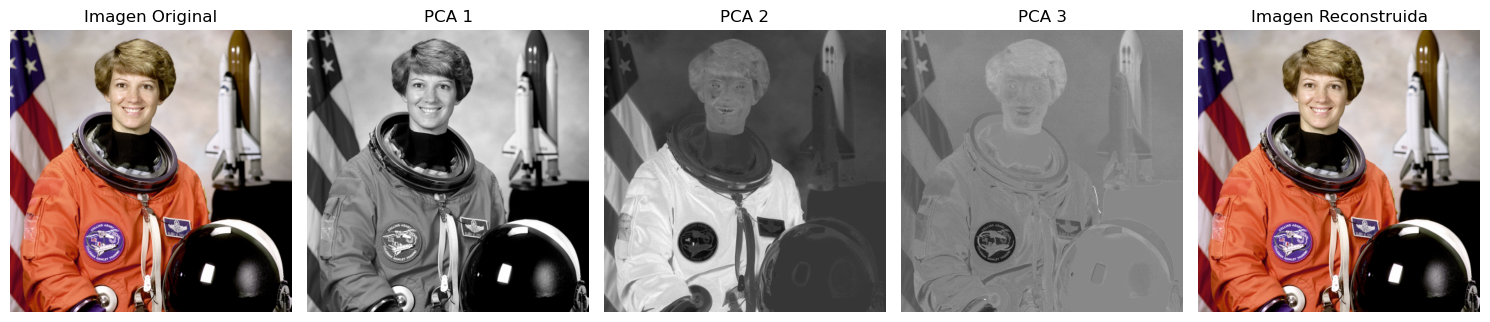

In [4]:
from skimage import data

# Cargar la imagen de entrada y normalizarla
image = data.astronaut() / 255.0

# Convertir la imagen a un array 2D donde cada fila es un píxel y cada columna es un canal de color
image_reshaped = image.reshape(-1, 3)

# Aplicar PCA para extraer sus componentes principales
pca = PCA()
image_pca = pca.fit_transform(image_reshaped)
image_components = image_pca.reshape(image.shape[0], image.shape[1], -1)

# Reconstruir la imagen a partir de sus componentes principales
reconstructed_image = pca.inverse_transform(image_pca).reshape(image.shape)

# Clip los valores para asegurarse de que estén en el rango [0, 1]
reconstructed_image = np.clip(reconstructed_image, 0, 1)

# Mostrar las imágenes obtenidas
plt.figure(figsize=(15, 5))
plt.subplot(1, 5, 1); plt.imshow(image); plt.title('Imagen Original'); plt.axis('off')
plt.subplot(1, 5, 2); plt.imshow(image_components[...,0], cmap='gray'); plt.title('PCA 1'); plt.axis('off')
plt.subplot(1, 5, 3); plt.imshow(image_components[...,1], cmap='gray'); plt.title('PCA 2'); plt.axis('off')
plt.subplot(1, 5, 4); plt.imshow(image_components[...,2], cmap='gray'); plt.title('PCA 3'); plt.axis('off')
plt.subplot(1, 5, 5); plt.imshow(reconstructed_image); plt.title('Imagen Reconstruida'); plt.axis('off')
plt.tight_layout()
plt.show()

Al descomponer la imagen original en sus componentes principales, podemos observar cómo cada uno captura diferentes aspectos de la información visual. El componente PCA 1, que es el de mayor varianza, se corresponde con los detalles más prominentes y contrastados de la imagen, mientras que el resto capturan detalles más sutiles. La alta fidelidad de la imagen reconstruida con respecto a la original evidencia la efectividad del PCA para la reducción de dimensionalidad y la compresión de imágenes.

### Agrupamiento (clustering)

El agrupamiento ([clustering](https://en.wikipedia.org/wiki/Cluster_analysis)) es una técnica de aprendizaje no supervisado que clasifica los datos en clústeres en base a sus similitudes. La capacidad de extraer la estructura subyacente de los datos hace del clustering una herramienta fundamental en el procesamiento de imágenes, permitiendo aplicaciones como la compresión, segmentación y mejora de la caracterización visual, entre muchas otras. A continuación, revisaremos algunas aplicaciones relevantes.

#### Cuantización de Imágenes con K-means

La cuantización de imágenes mediante clustering busca agrupar píxeles similares y reemplazarlos con el color promedio del clúster, permitiendo así la compresión y facilitando su análisis. Uno de los métodos de agrupamiento más utilizados es [K-means](https://en.wikipedia.org/wiki/K-means_clustering), el cual divide los datos en *k* clústeres, asignando cada muestra al clúster más cercano a su centroide. El proceso se realiza de forma iterativa, recalculando los centroides y reasignando los puntos hasta estabilizar las asignaciones, con el objetivo de minimizar la variación dentro de los clústeres y maximizar la separación entre ellos. El siguiente ejemplo muestra cómo utilizar el algoritmo K-means de *scikit-learn* para reducir el número de colores de una imagen dada.

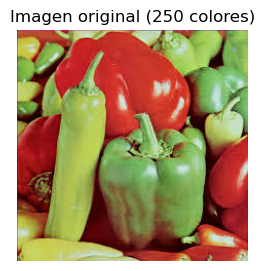

K-means con 64 colores terminado en 0.177s.
Predicción de índices de color terminada en 0.179s.
K-means con 32 colores terminado en 0.081s.
Predicción de índices de color terminada en 0.082s.
K-means con 16 colores terminado en 0.051s.
Predicción de índices de color terminada en 0.052s.
K-means con 4 colores terminado en 0.028s.
Predicción de índices de color terminada en 0.029s.


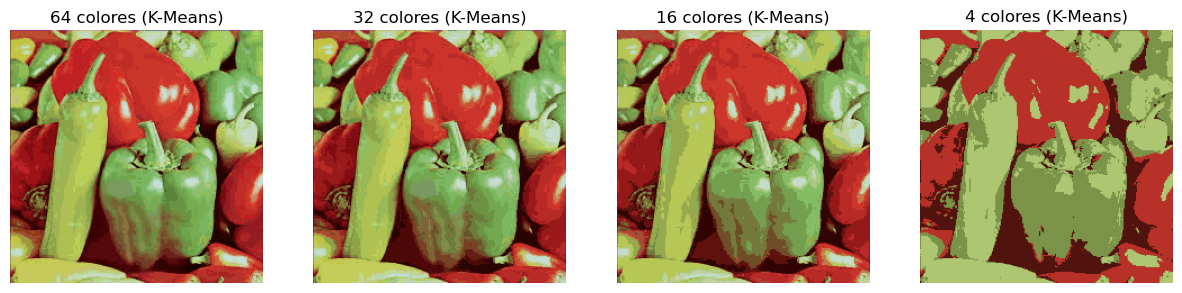

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from skimage.io import imread
from skimage import img_as_float
from sklearn.utils import shuffle
from time import time

# Cargar la imagen RGB
pepper = imread("./images/pepper.jpg")

# Mostrar la imagen original
plt.figure(figsize=(3, 3))
plt.imshow(pepper)
plt.title(f'Imagen original ({len(np.unique(pepper))} colores)')
plt.axis('off')
plt.show()

# Número de colores para la cuantización
n_colors = 64

# Convertir a flotantes y normalizar
pepper = img_as_float(pepper)

# Transformar la imagen en un array 2D
w, h, d = pepper.shape
image_array = np.reshape(pepper, (w * h, d))

def recreate_image(codebook, labels, w, h):
    """Crear la imagen cuantizada a partir del código y las etiquetas"""
    d = codebook.shape[1]
    image = np.zeros((w, h, d))
    for i in range(w):
        for j in range(h):
            image[i, j] = codebook[labels[i * h + j]]
    return image

# Mostrar la imagen original y todos los resultados de la cuantización
plt.figure(figsize=(15, 5))
for i, k in enumerate([64, 32, 16, 4], start=1):
    t0 = time()
    plt.subplot(1, 4, i)
    plt.axis('off')
    image_array_sample = shuffle(image_array, random_state=0)[:1000] # muestra aleatoria de 1000 píxeles
    kmeans = KMeans(n_clusters=k, random_state=0, n_init=10).fit(image_array_sample)
    print(f"K-means con {k} colores terminado en {time() - t0:.3f}s.")
    # Obtener etiquetas para todos los puntos
    labels = kmeans.predict(image_array)
    print(f"Predicción de índices de color terminada en {time() - t0:.3f}s.")
    plt.title(f'{k} colores (K-Means)', size=12)
    plt.imshow(recreate_image(kmeans.cluster_centers_, labels, w, h))
plt.show()

Los resultados muestran cómo la imagen se degrada gradualmente al considerar menos colores, pero mantiene suficiente información visual sobre las regiones más relevantes de la imagen al aplicar el agrupamiento.


#### Clustering Espectral para Segmentación

El [clustering espectral](https://en.wikipedia.org/wiki/Spectral_clustering) es una técnica avanzada de agrupamiento que transforma los datos originales para capturar la estructura de los grupos en el espacio de los vectores propios del laplaciano de la matriz de similitud de los datos. Este proceso identifica puntos de inflexión entre las similitudes de las muestras, permitiendo detectar regiones y estructuras intrínsecas en los datos, especialmente en casos complejos. A continuación, se presenta un ejemplo de uso para segmentación.

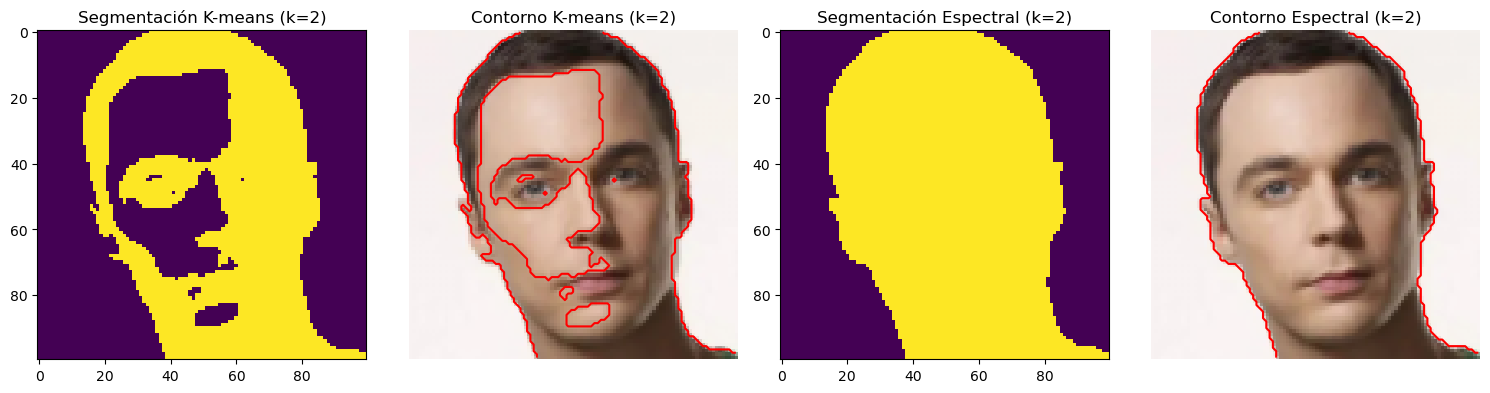

In [6]:
from sklearn import cluster
from skimage.io import imread
from skimage.color import rgb2gray
from skimage.transform import resize
import matplotlib.pyplot as plt
import numpy as np

# Cargar y redimensionar la imagen
im = resize(imread('./images/sheldon.jpg'), (100, 100, 3), anti_aliasing=True)
img_gray = rgb2gray(im)

# Parámetro k para la segmentación binaria
k = 2

# Convertir la imagen a un array 2D
X = np.reshape(im, (-1, im.shape[-1]))

# Aplicar K-means
kmeans = cluster.MiniBatchKMeans(n_clusters=k, random_state=0, n_init=10)
kmeans.fit(X)
kmeans_labels = kmeans.predict(X)
kmeans_labels_reshaped = np.reshape(kmeans_labels, im.shape[:2])

# Aplicar Clustering Espectral
spectral = cluster.SpectralClustering(n_clusters=k, random_state=0, affinity="nearest_neighbors")
spectral.fit(X)
spectral_labels = spectral.labels_.astype(int)
spectral_labels_reshaped = np.reshape(spectral_labels, im.shape[:2])

# Figura para mostrar los resultados
plt.figure(figsize=(15, 5))

# Mostrar resultados de K-means
plt.subplot(141)
plt.imshow(kmeans_labels_reshaped)
plt.title('Segmentación K-means (k=2)', size=12)
plt.subplot(142)
plt.imshow(im)
plt.contour(kmeans_labels_reshaped == 0, colors='red')
plt.axis('off')
plt.title('Contorno K-means (k=2)', size=12)

# Mostrar resultados de Clustering Espectral
plt.subplot(143)
plt.imshow(spectral_labels_reshaped)
plt.title('Segmentación Espectral (k=2)', size=12)
plt.subplot(144)
plt.imshow(im)
plt.contour(spectral_labels_reshaped == 0, colors='red')
plt.axis('off')
plt.title('Contorno Espectral (k=2)', size=12)

plt.tight_layout()
plt.show()

Como podemos observar, el clustering espectral diferencia mejor entre el primer plano y el fondo debido a su capacidad para identificar estructuras globales en los datos, mientras que K-means tiende a confundir regiones con tonos de color similares, resultando en una segmentación menos precisa.

<div style="page-break-before: always;"></div>

____
 <a class='anchor' id='supervisado12'></a>
 
## Aprendizaje Supervisado

El [aprendizaje supervisado](https://en.wikipedia.org/wiki/Supervised_learning) consiste en utilizar datos etiquetados para entrenar modelos que puedan realizar tareas de clasificación o predicción con alta precisión. En el contexto del procesamiento de imágenes y la visión por computadora, este enfoque permite que los algoritmos aprendan de ejemplos de entrenamiento y generalicen a nuevas imágenes no vistas previamente. En este apartado, revisaremos algunas técnicas relevantes y su aplicación práctica.

### Clasificación de Imágenes

La clasificación de imágenes consiste en asignar una o varias etiquetas semánticas a cada imagen en función de su contenido visual. Utilizando algoritmos de aprendizaje supervisado, como K-Nearest Neighbors ([KNN](https://en.wikipedia.org/wiki/K-nearest_neighbors_algorithm)) y Support Vector Machines ([SVM](https://en.wikipedia.org/wiki/Support_vector_machine)), es posible entrenar modelos que detecten automáticamente patrones y características distintivas en las imágenes. A continuación, exploraremos cómo utilizar de forma directa algunas técnicas clasicas para clasificar imágenes.

2025-07-13 23:45:24.887613: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-13 23:45:25.505330: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-13 23:45:26.095862: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752443126.524633    5613 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752443126.649135    5613 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-13 23:45:28.121592: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU ins

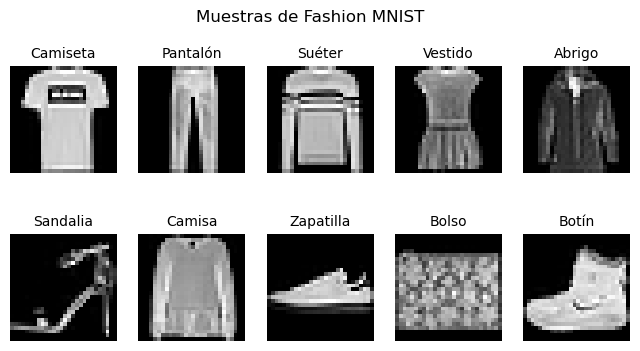

Entrenando KNN...
Entrenando SVM...
Evaluando los modelos en el conjunto de test...
Informe de clasificación de KNN en el conjunto de prueba:
               precision    recall  f1-score   support

    Camiseta       0.71      0.81      0.76      1000
    Pantalón       0.98      0.93      0.96      1000
      Suéter       0.62      0.71      0.67      1000
     Vestido       0.86      0.80      0.83      1000
      Abrigo       0.73      0.64      0.68      1000
    Sandalia       0.99      0.76      0.86      1000
      Camisa       0.53      0.53      0.53      1000
   Zapatilla       0.84      0.92      0.88      1000
       Bolso       0.97      0.92      0.94      1000
       Botín       0.84      0.96      0.90      1000

    accuracy                           0.80     10000
   macro avg       0.81      0.80      0.80     10000
weighted avg       0.81      0.80      0.80     10000

Matriz de confusión de KNN en el conjunto de prueba:



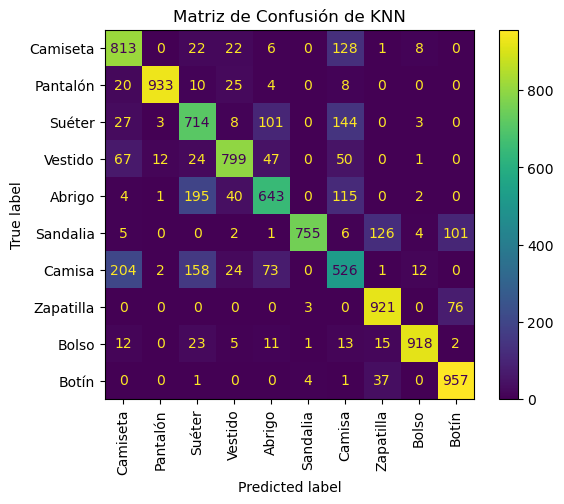

Informe de clasificación de SVM en el conjunto de prueba:
               precision    recall  f1-score   support

    Camiseta       0.73      0.80      0.76      1000
    Pantalón       0.96      0.95      0.95      1000
      Suéter       0.65      0.73      0.69      1000
     Vestido       0.82      0.81      0.82      1000
      Abrigo       0.72      0.66      0.69      1000
    Sandalia       0.90      0.90      0.90      1000
      Camisa       0.56      0.49      0.52      1000
   Zapatilla       0.88      0.90      0.89      1000
       Bolso       0.94      0.92      0.93      1000
       Botín       0.92      0.91      0.92      1000

    accuracy                           0.81     10000
   macro avg       0.81      0.81      0.81     10000
weighted avg       0.81      0.81      0.81     10000

Matriz de confusión de SVM en el conjunto de prueba:



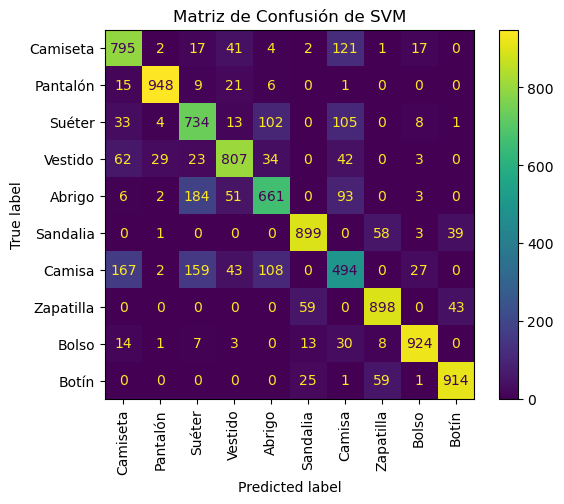

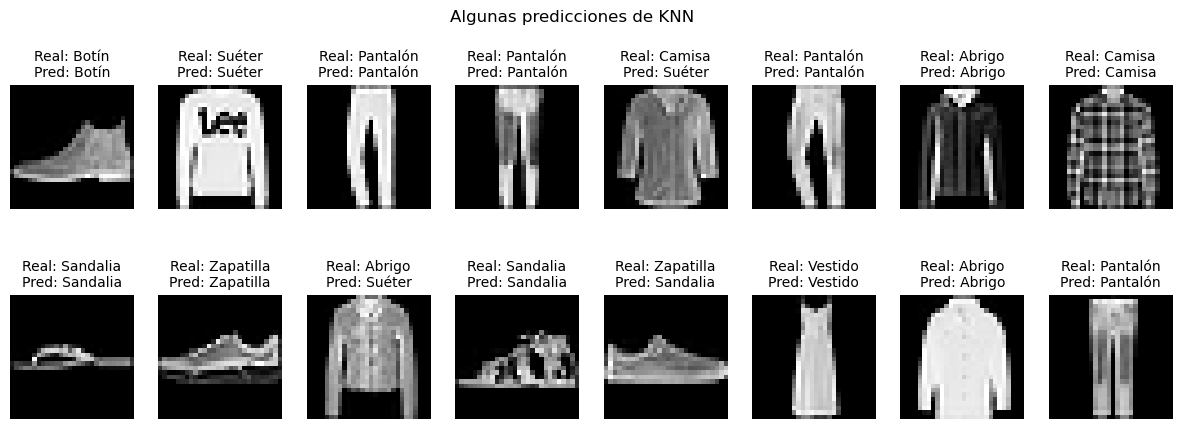

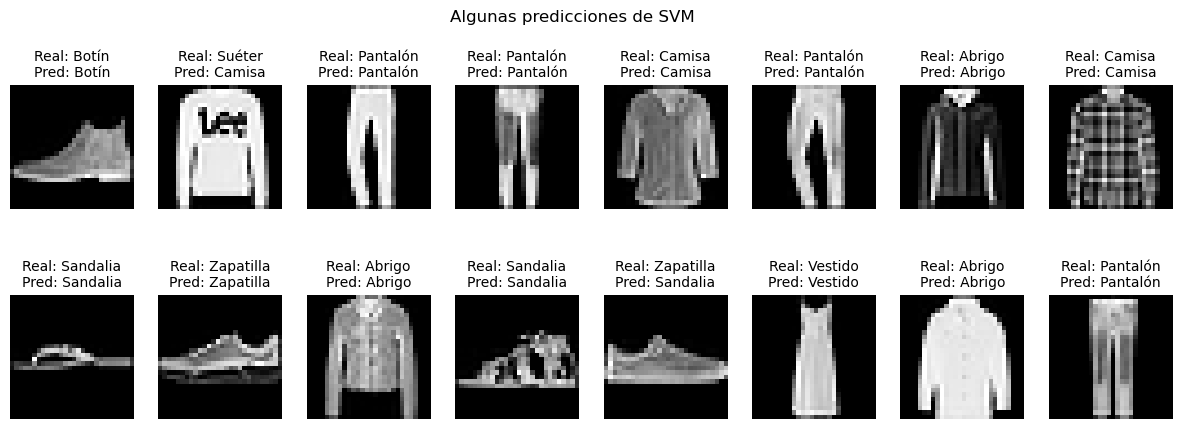

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from keras.datasets import fashion_mnist

# Cargar el conjunto de datos Fashion MNIST
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Mostrar una imagen por clase del conjunto de datos
def plot_sample_images(X, y, class_names, title):
    plt.figure(figsize=(8, 4))
    for i in range(len(class_names)):
        idxs = np.where(y == i)[0]
        plt.subplot(2, len(class_names)//2, i + 1)
        plt.imshow(X[idxs[0]], cmap='gray')
        plt.axis('off')
        plt.title(class_names[i], size=10)
    plt.suptitle(title, size=12)
    plt.show()

class_names = ["Camiseta", "Pantalón", "Suéter", "Vestido", "Abrigo",
               "Sandalia", "Camisa", "Zapatilla", "Bolso", "Botín"]

plot_sample_images(X_train, y_train, class_names, "Muestras de Fashion MNIST")

# Reducir el tamaño del conjunto de datos para un entrenamiento más rápido
X_train_small, _, y_train_small, _ = train_test_split(X_train, y_train, train_size=0.1, stratify=y_train, random_state=42)

# Preprocesar los datos
X_train_small = X_train_small.reshape(X_train_small.shape[0], -1) / 255.0
X_test = X_test.reshape(X_test.shape[0], -1) / 255.0

# Inicializar y entrenar el modelo KNN
print("Entrenando KNN...")
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_small, y_train_small)

# Inicializar y entrenar el modelo SVM
print("Entrenando SVM...")
svm = SVC(kernel='linear')
svm.fit(X_train_small, y_train_small)

# Evaluar ambos modelos en el conjunto de test
print("Evaluando los modelos en el conjunto de test...")
y_test_pred_knn = knn.predict(X_test)
y_test_pred_svm = svm.predict(X_test)

# Crear y mostrar el informe de clasificación y la matriz de confusión de KNN
print("Informe de clasificación de KNN en el conjunto de prueba:\n", classification_report(y_test, y_test_pred_knn, target_names=class_names))
print("Matriz de confusión de KNN en el conjunto de prueba:\n")
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_knn, display_labels=class_names, xticks_rotation='vertical')
plt.title('Matriz de Confusión de KNN')
plt.show()

# Crear y mostrar el informe de clasificación y la matriz de confusión de SVM
print("Informe de clasificación de SVM en el conjunto de prueba:\n", classification_report(y_test, y_test_pred_svm, target_names=class_names))
print("Matriz de confusión de SVM en el conjunto de prueba:\n")
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_svm, display_labels=class_names, xticks_rotation='vertical')
plt.title('Matriz de Confusión de SVM')
plt.show()

# Visualizar algunas predicciones
def plot_images(images, labels_true, labels_pred, title, num_imgs=16):
    plt.figure(figsize=(15, 5))
    for i in range(num_imgs):
        plt.subplot(2, 8, i + 1)
        plt.imshow(images[i].reshape(28, 28), cmap='gray')
        plt.title(f'Real: {class_names[labels_true[i]]}\nPred: {class_names[labels_pred[i]]}', size=10)
        plt.axis('off')
    plt.suptitle(title, size=12)
    plt.show()

# Mostrar algunas predicciones KNN
plot_images(X_test[:16], y_test[:16], y_test_pred_knn[:16], "Algunas predicciones de KNN", 16)

# Mostrar algunas predicciones SVM
plot_images(X_test[:16], y_test[:16], y_test_pred_svm[:16], "Algunas predicciones de SVM", 16)

Este ejemplo compara los algoritmos KNN y SVM utilizando el conjunto de datos [Fashion MNIST](https://github.com/zalandoresearch/fashion-mnist). Inicialmente, se visualiza una muestra representativa de cada clase para comprender mejor el conjunto de datos. La caracterización de las imágenes se realiza mediante una simple vectorización de los píxeles, transformando cada imagen en una fila de valores de intensidad. Este enfoque funciona adecuadamente para conjuntos de datos relativamente simples. Sin embargo, imágenes más complejas requerirán técnicas de caracterización más avanzadas para capturar de forma más efectiva los patrones visuales de las imágenes.

### Regresión de Imágenes

Así como la clasificación busca predecir etiquetas, el problema de regresión se enfoca en estimar uno o más valores numéricos, en este caso, a partir de una imagen de entrada. Un ejemplo de este tipo de técnicas son los algoritmos supervisados de [súper-resolución](https://en.wikipedia.org/wiki/Super-resolution_imaging), que tienen como objetivo aumentar la resolución y calidad de las imágenes. En este apartado, veremos una red neuronal convolucional ([CNN](https://en.wikipedia.org/wiki/Convolutional_neural_network)) básica de regresión aplicada a la súper-resolución de imágenes.

Epoch 1/20


2025-07-13 23:45:56.234936: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
2025-07-13 23:45:56.298154: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 31360000 exceeds 10% of free system memory.


 2/32 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - loss: 0.1630

2025-07-13 23:45:57.590223: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 32614400 exceeds 10% of free system memory.
2025-07-13 23:45:57.596699: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 32614400 exceeds 10% of free system memory.
2025-07-13 23:45:57.697523: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 32614400 exceeds 10% of free system memory.
2025-07-13 23:45:57.698738: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 32614400 exceeds 10% of free system memory.


32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 132ms/step - loss: 0.1326 - val_loss: 0.0347
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 118ms/step - loss: 0.0274 - val_loss: 0.0171
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 129ms/step - loss: 0.0152 - val_loss: 0.0133
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 122ms/step - loss: 0.0125 - val_loss: 0.0118
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 125ms/step - loss: 0.0112 - val_loss: 0.0112
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 125ms/step - loss: 0.0103 - val_loss: 0.0103
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 123ms/step - loss: 0.0097 - val_loss: 0.0098
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 124ms/step - loss: 0.0095 - val_loss: 0.0094
Epoch 9/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 124ms/step - loss: 0.0092 - val_loss: 0.0092
Epoch 10/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 125ms/step - loss: 0.0087 - val_loss: 0.0089
Epoch 11/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 123ms/step - loss: 0.0087 - val_loss: 0.0088
Epoch 12/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 125ms/step - loss: 0.

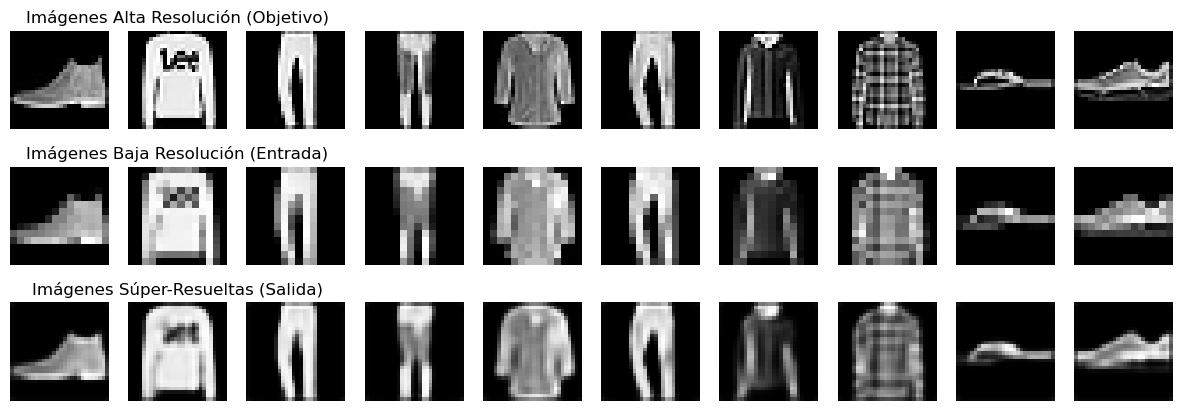

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.layers import Input, Conv2D, UpSampling2D
from keras.models import Model
from keras.datasets import fashion_mnist

# Cargar y preprocesar los datos Fashion MNIST
(X_train, _), (X_test, _) = fashion_mnist.load_data()
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Limitamos el numero de muestras para un entrenamiento más rápido
X_train = X_train[:1000]

# Asegurarse de que las imágenes tengan una dimensión de canal
X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

# Reducir la resolución de las imágenes
low_res_X_train = tf.image.resize(X_train, [14, 14])
low_res_X_test = tf.image.resize(X_test, [14, 14])

# Definir el modelo de súper-resolución
input_img = Input(shape=(14, 14, 1))
x = UpSampling2D(size=(2, 2))(input_img) # interpolación inicial
x = Conv2D(64, (9, 9), activation='relu', padding='same')(x) # primera capa de convolución
x = Conv2D(32, (1, 1), activation='relu', padding='same')(x) # segunda capa de convolución
output_img = Conv2D(1, (5, 5), activation='sigmoid', padding='same')(x) # capa de salida

model = Model(input_img, output_img)
model.compile(optimizer='adam', loss='mse')

# Entrenar el modelo
model.fit(low_res_X_train, X_train, epochs=20, batch_size=32, validation_data=(low_res_X_test, X_test))

# Evaluar el modelo en algunas imágenes de prueba
num_tests = 10
low_res_test_imgs = low_res_X_test[:num_tests]
high_res_test_imgs = model.predict(low_res_test_imgs)

# Mostrar los resultados
def plot_comparison(low_res, high_res, generated):
    num_images = low_res.shape[0]
    plt.figure(figsize=(15, 5))
    for i in range(num_images):
        plt.subplot(3, num_images, i + 1)
        plt.imshow(high_res[i].reshape(28, 28), cmap='gray')
        plt.axis('off')
        if i == 1:
            plt.title('Imágenes Alta Resolución (Objetivo)', fontsize=12)
        
        plt.subplot(3, num_images, i + num_images + 1)
        plt.imshow(low_res[i].numpy().reshape(14, 14), cmap='gray')
        plt.axis('off')
        if i == 1:
            plt.title('Imágenes Baja Resolución (Entrada)', fontsize=12)
        
        plt.subplot(3, num_images, i + 2*num_images + 1)
        plt.imshow(generated[i].reshape(28, 28), cmap='gray')
        plt.axis('off')
        if i == 1:
            plt.title('Imágenes Súper-Resueltas (Salida)', fontsize=12)
    
    plt.show()

plot_comparison(low_res_test_imgs, X_test[:num_tests], high_res_test_imgs)

El código anterior implementa un red convolucional básica de súper-resolución y la aplica sobre el conjunto de datos Fashion MNIST. Tras realizar un entrenamiento con pares de imágenes de baja y alta resolución, el modelo es capaz de generar imágenes súper-resueltas que mejoran significativamente la calidad de las imágenes de entrada.

<div style="page-break-before: always;"></div>

___
 <a class='anchor' id='ejercicios12'></a>

## Ejercicios de práctica

### *Ejercicio 1. Conteo de Árboles*

En este ejercicio, implementarás un programa en Python para detectar y contar árboles en una imagen aérea utilizando la técnica de coincidencia de plantillas (template matching). Comienza cargando la imagen `./images/trees.jpg` y encárgate de procesarla adecuadamente. Luego, selecciona manualmente una región de la imagen que contenga un árbol para usarla como plantilla. Seguidamente, aplica el método de coincidencia de plantillas de *OpenCV* para buscar áreas en la imagen que se asemejen a la plantilla del árbol. Establece un umbral adeacuado para lograr alcanzar todas detecciones y aplica la técnica de supresión de no máximos (Non-Maximum Suppression) para eliminar las detecciones redundantes, es decir, aquellas que están demasiado cerca unas de otras y representan el mismo árbol. Finalmente, dibuja rectángulos alrededor de las detecciones restantes y muestra la imagen original junto con la imagen que contiene los árboles detectados, indicando su número total.


<div style="text-align: center; margin-bottom: 20px;">
    <h3>Resultado esperado</h3>
</div>
<div style="display:flex; justify-content:center; align-items:center;">
    <img src="./images/ej1_trees.jpg" style="width:60%; height:auto; margin-right: 50px;">
</div>
<br><br>

trees_p.jpg ha sido recortada a mano

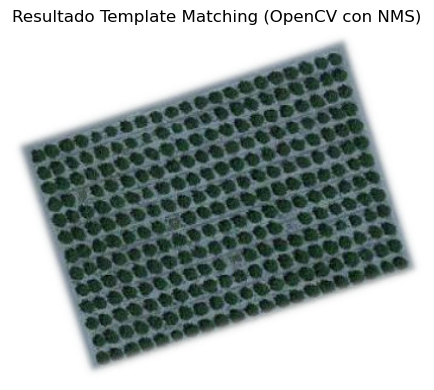

In [9]:
import cv2
import time
import numpy as np
import matplotlib.pyplot as plt

# Cargar la imagen principal y la plantilla
image = cv2.imread('./images/trees.jpg')
template = cv2.imread('./images/trees_p.jpg')

# Convertimos a RGB para visualizar con matplotlib
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
template_rgb = cv2.cvtColor(template, cv2.COLOR_BGR2RGB)

# Convertir las imágenes a escala de grises
imagen_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
template_gray = cv2.cvtColor(template, cv2.COLOR_BGR2GRAY)

# Aplicar el método de coincidencia de plantillas de OpenCV
#time_start2 = time.time()
result2 = cv2.matchTemplate(imagen_gray, template_gray, cv2.TM_CCOEFF_NORMED)
#time_end2 = time.time()
#print('Tiempo de ejecución: {:.2f} segundos'.format(time_end2 - time_start2))

# Buscar coincidencias con el umbral definido anteriormente
threshold = 0.75
locations2 = np.where(result2 >= threshold)
# Obtener las dimensiones de la plantilla
w, h = template_gray.shape[::-1]
# Crear una lista de las cajas delimitadoras y sus scores
boxes = []
scores = []
for pt in zip(*locations2[::-1]):
    top_left = pt
    bottom_right = (top_left[0] + w, top_left[1] + h)
    boxes.append([top_left[0], top_left[1], bottom_right[0] - top_left[0], bottom_right[1] - top_left[1]])
    scores.append(result2[pt[1], pt[0]])

# Aplicar la supresión de no máximos
indices = cv2.dnn.NMSBoxes(boxes, scores, score_threshold=threshold, nms_threshold=0.3)

# Dibujar rectángulos alrededor de las coincidencias después de la supresión de no máximos
for i in indices:
    box = boxes[i]
    top_left = (box[0], box[1])
    bottom_right = (box[0] + box[2], box[1] + box[3])
    cv2.rectangle(image_rgb, top_left, bottom_right, (255, 0, 0), 2)

# Mostrar la imagen resultante con las coincidencias marcadas
plt.figure(figsize=(8, 4))
plt.imshow(image)
plt.title('Resultado Template Matching (OpenCV con NMS)')
plt.axis('off')
plt.tight_layout()
plt.show()

Tiempo de ejecución: 0.00 segundos


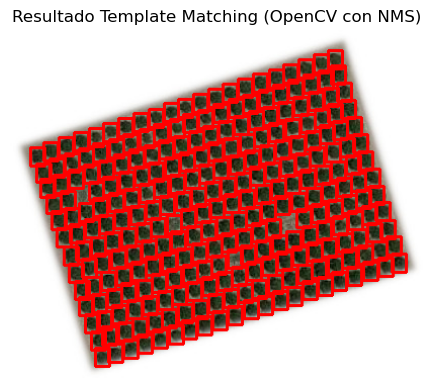

In [10]:


# Cargar la imagen principal y la plantilla
image = cv2.imread('./images/trees.jpg')
template = cv2.imread('./images/trees_p.jpg')

# Convertimos a RGB para visualizar con matplotlib
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
template_rgb = cv2.cvtColor(template, cv2.COLOR_BGR2RGB)

# Convertir las imágenes a escala de grises
imagen_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
template_gray = cv2.cvtColor(template, cv2.COLOR_BGR2GRAY)

# Aplicar el método de coincidencia de plantillas de OpenCV
time_start2 = time.time()
result2 = cv2.matchTemplate(imagen_gray, template_gray, cv2.TM_CCOEFF_NORMED)
time_end2 = time.time()
print('Tiempo de ejecución: {:.2f} segundos'.format(time_end2 - time_start2))

# Buscar coincidencias con el umbral definido anteriormente
threshold = 0.50
locations2 = np.where(result2 >= threshold)

# Obtener las dimensiones de la plantilla
w, h = template_gray.shape[::-1]

# Crear una lista de las cajas delimitadoras y sus scores
boxes = []
scores = []
for pt in zip(*locations2[::-1]):
    top_left = pt
    boxes.append([top_left[0], top_left[1], w, h])
    scores.append(result2[pt[1], pt[0]])

# Aplicar la supresión de no máximos
indices = cv2.dnn.NMSBoxes(boxes, scores, score_threshold=threshold, nms_threshold=0.3)

# Dibujar rectángulos alrededor de las coincidencias después de la supresión de no máximos
if len(indices) > 0:
    for i in indices.flatten():
        box = boxes[i]
        top_left = (box[0], box[1])
        bottom_right = (box[0] + box[2], box[1] + box[3])
        cv2.rectangle(image_rgb, top_left, bottom_right, (255, 0, 0), 2)

# Mostrar la imagen resultante con las coincidencias marcadas
plt.figure(figsize=(8, 4))
plt.imshow(image_rgb)
plt.title('Resultado Template Matching (OpenCV con NMS)')
plt.axis('off')
plt.tight_layout()
plt.show()


Tiempo de ejecución: 0.00 segundos


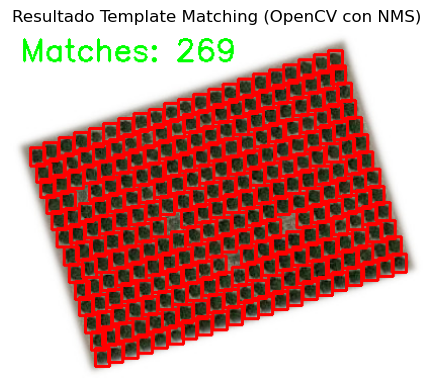

In [11]:
import cv2
import time
import numpy as np
import matplotlib.pyplot as plt

# Cargar la imagen principal y la plantilla
image = cv2.imread('./images/trees.jpg')
template = cv2.imread('./images/trees_p.jpg')

# Convertimos a RGB para visualizar con matplotlib
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
template_rgb = cv2.cvtColor(template, cv2.COLOR_BGR2RGB)

# Convertir las imágenes a escala de grises
imagen_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
template_gray = cv2.cvtColor(template, cv2.COLOR_BGR2GRAY)

# Aplicar el método de coincidencia de plantillas de OpenCV
time_start2 = time.time()
result2 = cv2.matchTemplate(imagen_gray, template_gray, cv2.TM_CCOEFF_NORMED)
time_end2 = time.time()
print('Tiempo de ejecución: {:.2f} segundos'.format(time_end2 - time_start2))

# Buscar coincidencias con el umbral definido anteriormente
threshold = 0.68
locations2 = np.where(result2 >= threshold)

# Obtener las dimensiones de la plantilla
w, h = template_gray.shape[::-1]

# Crear una lista de las cajas delimitadoras y sus scores
boxes = []
scores = []
for pt in zip(*locations2[::-1]):
    top_left = pt
    boxes.append([top_left[0], top_left[1], w, h])
    scores.append(result2[pt[1], pt[0]])

# Aplicar la supresión de no máximos
indices = cv2.dnn.NMSBoxes(boxes, scores, score_threshold=threshold, nms_threshold=0.3)

# Dibujar rectángulos alrededor de las coincidencias después de la supresión de no máximos
if len(indices) > 0:
    for i in indices.flatten():
        box = boxes[i]
        top_left = (box[0], box[1])
        bottom_right = (box[0] + box[2], box[1] + box[3])
        cv2.rectangle(image_rgb, top_left, bottom_right, (255, 0, 0), 2)

# Mostrar el número de coincidencias en la imagen
num_matches = len(indices)
cv2.putText(
    image_rgb, 
    f'Matches: {num_matches}', 
    (10, 30), 
    cv2.FONT_HERSHEY_SIMPLEX, 
    1, 
    (0, 255, 0), 
    2
)

# Mostrar la imagen resultante con las coincidencias marcadas
plt.figure(figsize=(8, 4))
plt.imshow(image_rgb)
plt.title('Resultado Template Matching (OpenCV con NMS)')
plt.axis('off')
plt.tight_layout()
plt.show()

### *Ejercicio 2. Fusión de Imágenes*

Desarrolla un programa en Python para realizar la fusión de imágenes utilizando el Análisis de Componentes Principales (PCA). Comienza cargando dos imágenes de la misma escena: una imagen a color de baja resolución (`./images/guepard_small_rgb.jpg`) y una imagen en blanco y negro de alta resolución (`./images/guepard_big_bw.jpg`). Si lo consideras oportuno, puedes normalizar los valores de los píxeles dividiendo por 255. A continuación, aplica el PCA en la imagen a color de baja resolución para transformar los datos en sus componentes principales. Después, interpola los componentes principales a la resolución de la imagen en blanco y negro de alta resolución y reemplaza el primer componente principal interpolado con la imagen en blanco y negro de alta resolución. Posteriormente, reconstruye la imagen a color a partir de los componentes principales modificados utilizando la transformación inversa del PCA. Asegúrate de que los valores de los píxeles de la imagen reconstruida estén en el rango inicial. Finalmente, ecualiza la imagen fusionada para que coincida con la imagen a color de baja resolución y visualiza las imágenes originales y la imagen fusionada en una sola figura.

<div style="text-align: center; margin-bottom: 20px;">
    <h3>Resultado esperado</h3>
</div>
<div style="display:flex; justify-content:center; align-items:center;">
    <img src="./images/ej2_guepard.jpg" style="width:80%; height:auto; margin-right: 50px;">
</div>
<br><br>

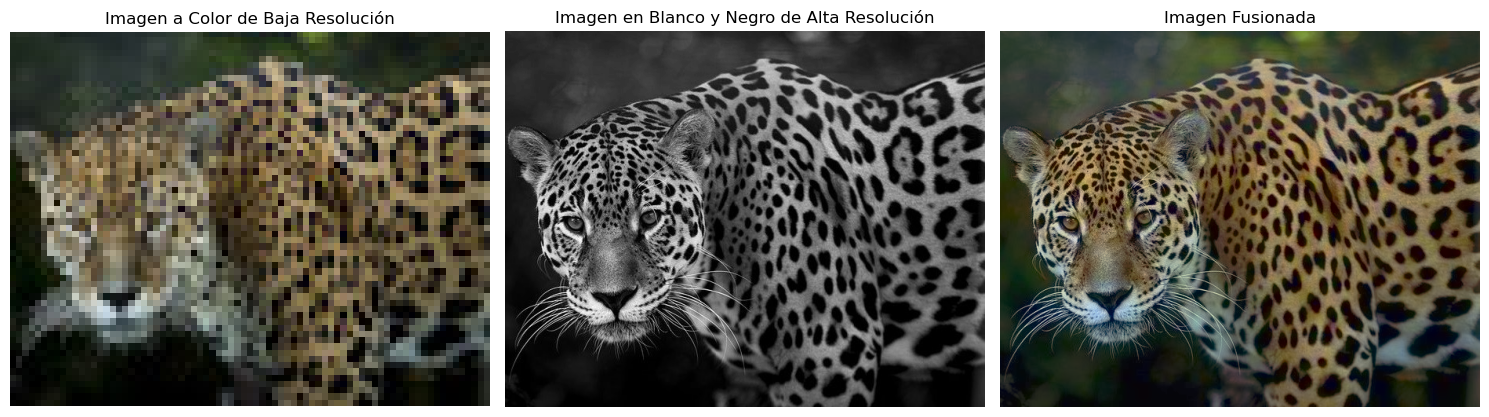

In [12]:
import numpy as np
from skimage.io import imread
from skimage.color import rgb2gray
from skimage.transform import resize
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt

# Cargar las imágenes
low_res_color = imread('./images/guepard_small_rgb.jpg') / 255.0
high_res_bw = imread('./images/guepard_big_bw.jpg') / 255.0

# Convertir la imagen a color de baja resolución a un array 2D
low_res_color_reshaped = low_res_color.reshape(-1, 3)

# Aplicar PCA a la imagen a color de baja resolución
pca = PCA()
low_res_color_pca = pca.fit_transform(low_res_color_reshaped)

# Interpolar los componentes principales a la resolución de la imagen en blanco y negro de alta resolución
high_res_shape = high_res_bw.shape
low_res_shape = low_res_color.shape[:2]
interpolated_components = np.zeros((high_res_shape[0], high_res_shape[1], low_res_color_pca.shape[1]))

for i in range(low_res_color_pca.shape[1]):
    component = low_res_color_pca[:, i].reshape(low_res_shape)
    interpolated_component = resize(component, high_res_shape, anti_aliasing=True)
    interpolated_components[:, :, i] = interpolated_component

# Reemplazar el primer componente principal interpolado con la imagen en blanco y negro de alta resolución
interpolated_components[:, :, 0] = high_res_bw

# Reconstruir la imagen a color a partir de los componentes principales modificados
reconstructed_image_pca = interpolated_components.reshape(-1, interpolated_components.shape[2])
reconstructed_image = pca.inverse_transform(reconstructed_image_pca)
reconstructed_image = reconstructed_image.reshape(high_res_shape[0], high_res_shape[1], 3)

# Asegurarse de que los valores de los píxeles estén en el rango [0, 1]
reconstructed_image = np.clip(reconstructed_image, 0, 1)

# Ecualizar la imagen fusionada para que coincida con la imagen a color de baja resolución
def match_histograms(source, reference):
    matched = np.zeros_like(source)
    for i in range(3):
        src_hist, bins = np.histogram(source[:, :, i].flatten(), bins=256, range=[0, 1])
        ref_hist, _ = np.histogram(reference[:, :, i].flatten(), bins=256, range=[0, 1])
        src_cdf = np.cumsum(src_hist) / np.sum(src_hist)
        ref_cdf = np.cumsum(ref_hist) / np.sum(ref_hist)
        interp_values = np.interp(src_cdf, ref_cdf, bins[:-1])
        matched[:, :, i] = np.interp(source[:, :, i].flatten(), bins[:-1], interp_values).reshape(source[:, :, i].shape)
    return matched

fused_image = match_histograms(reconstructed_image, low_res_color)

# Mostrar las imágenes originales y la imagen fusionada
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(low_res_color)
plt.title('Imagen a Color de Baja Resolución')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(high_res_bw, cmap='gray')
plt.title('Imagen en Blanco y Negro de Alta Resolución')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(fused_image)
plt.title('Imagen Fusionada')
plt.axis('off')

plt.tight_layout()
plt.show()

### *Ejercicio 3. Análisis de Centroides*

Implementa un programa en Python para explorar cómo el tamaño de la muestra de datos afecta a los centroides obtenidos mediante el algoritmo de agrupamiento *KMeans*. Comienza cargando el conjunto de imágenes `Fashion MNIST` y prepara los datos para el clustering. A continuación, selecciona diferentes tamaños de muestras en orden creciente (100, 1000, 10000 y todas las muestras disponibles). Para cada tamaño, aplica *KMeans* con 10 clusters y visualiza los centroides resultantes en una figura, mostrando una fila de centroides para cada tamaño de muestra. Asegúrate de etiquetar claramente cada fila con el tamaño de la muestra correspondiente y cada columna con el número del cluster, para observar cómo varían los centroides con el tamaño de la muestra. Finalmente, reflexiona sobre las siguientes cuestiones: ¿Por qué los centroides van cambiando en cada ejecución? ¿Puedes identificar todas las clases en la última ejecución? Si no es así, indica qué clases observas que se están confundiendo y cuáles están sobrerrepresentadas a la vista de los centroides, y explica por qué.

<div style="text-align: center; margin-bottom: 20px;">
    <h3>Resultado esperado</h3>
</div>
<div style="display:flex; justify-content:center; align-items:center;">
    <img src="./images/ej3_centroids.jpg" style="width:80%; height:auto; margin-right: 50px;">
</div>
<br><br>

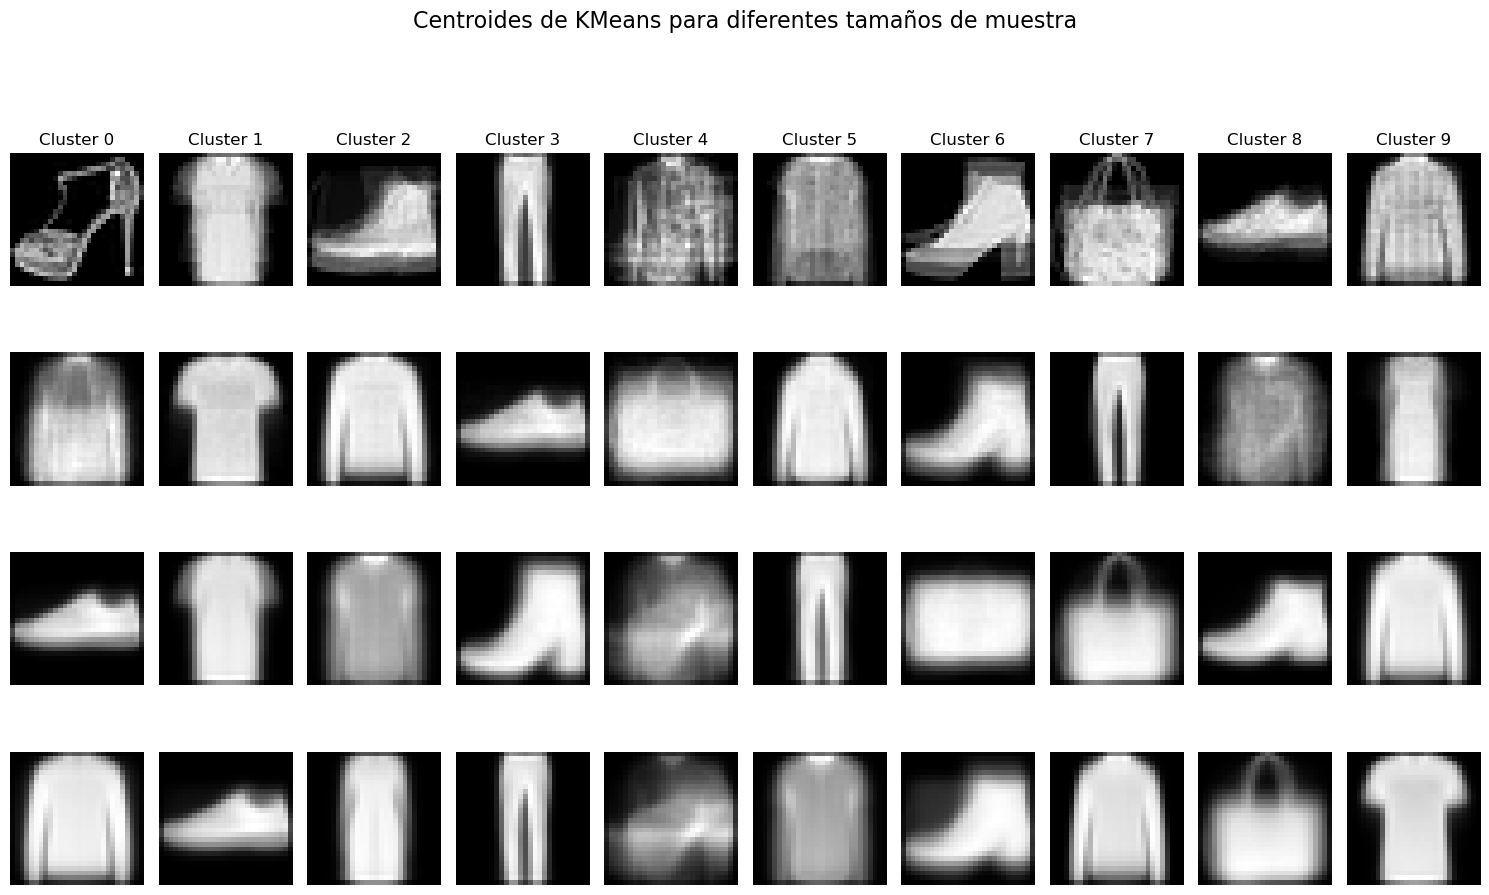

In [13]:
import numpy as np
from sklearn.cluster import KMeans
from keras.datasets import fashion_mnist

import matplotlib.pyplot as plt

# Cargar el conjunto de datos Fashion MNIST
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Preprocesar los datos
X_train = X_train.reshape(X_train.shape[0], -1) / 255.0

# Definir tamaños de muestra
sample_sizes = [100, 1000, 10000, len(X_train)]

# Inicializar la figura
plt.figure(figsize=(15, 10))

for i, size in enumerate(sample_sizes):
    # Seleccionar una muestra aleatoria del tamaño especificado
    X_sample = X_train[np.random.choice(X_train.shape[0], size, replace=False)]
    
    # Aplicar KMeans con 10 clusters
    kmeans = KMeans(n_clusters=10, random_state=0)
    kmeans.fit(X_sample)
    
    # Obtener los centroides
    centroids = kmeans.cluster_centers_
    
    # Visualizar los centroides
    for j in range(10):
        plt.subplot(len(sample_sizes), 10, i * 10 + j + 1)
        plt.imshow(centroids[j].reshape(28, 28), cmap='gray')
        plt.axis('off')
        if j == 0:
            plt.ylabel(f'Muestra: {size}', size=12)
        if i == 0:
            plt.title(f'Cluster {j}', size=12)

plt.suptitle('Centroides de KMeans para diferentes tamaños de muestra', size=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Ver análisis de resultados

<!-- 
¿Por qué los centroides van cambiando en cada ejecución?

Los centroides cambian en cada ejecución debido a la naturaleza estocástica del algoritmo KMeans. Este algoritmo inicia con una selección aleatoria de centroides, y esta selección inicial puede influir significativamente en los resultados finales. Aunque el algoritmo tiende a converger hacia una solución similar, la variabilidad en la selección inicial de centroides y las actualizaciones sucesivas durante el entrenamiento pueden llevar a diferentes configuraciones de centroides en cada ejecución. -->

<!-- 
¿Puedes identificar todas las clases en la última ejecución?

Al observar la fila correspondiente a la ejecución con todas las muestras, se puede identificar la mayoría de las clases, pero no todas están claramente diferenciadas. Comparando el aspecto visual de los centroides con los ejemplos de muestras de cada clase, vemos que hay una clase sobrerrepresentada y dos clases que se confunden:

- La clase que parece estar sobrerrepresentada es Botín (#6 y #10), donde parece que se identifican botines de caña alta y de caña baja.

- En cuanto a las clases que se confunden, podemos detectar Abrigo y Sandalia que parecen fusionarse en el centroide #1.

Estas confusiones son esperadas en algoritmos de clustering no supervisados, ya que el modelo agrupa las muestras basándose únicamente en similitudes de características sin información de etiquetas de clase. -->

### *Ejercicio 4. Clasificar Emociones*

Desarrolla un programa en Python para evaluar la eficacia del algoritmo K-Nearest Neighbors (KNN) en la clasificación de emociones faciales utilizando el conjunto de datos [FER-2013](https://www.kaggle.com/datasets/msambare/fer2013). Comienza cargando y preprocesando el conjunto de datos desde el archivo CSV ubicado en `./images/fer2013.csv`. Para ello, puedes utilizar la función `preprocess_csv_data` proporcionada más abajo. Seguidamente, entrena y evalúa el clasificador KNN con diferentes valores de vecinos más cercanos (k=1 y k=5) y muestra las matrices de confusión resultantes para cada valor de k en una figura, permitiendo así comparar visualmente el rendimiento del clasificador con diferentes configuraciones de vecinos más cercanos. ¿Cuáles son las principales diferencias que observas entre las matrices de confusión obtenidas con k=1 y k=5? Razona tu respuesta en términos de la variabilidad intra-clase e inter-clase.

<div style="text-align: center; margin-bottom: 20px;">
    <h3>Resultado esperado</h3>
</div>
<div style="display:flex; justify-content:center; align-items:center;">
    <img src="./images/ej4_confusion.jpg" style="width:80%; height:auto; margin-right: 50px;">
</div>
<br><br>

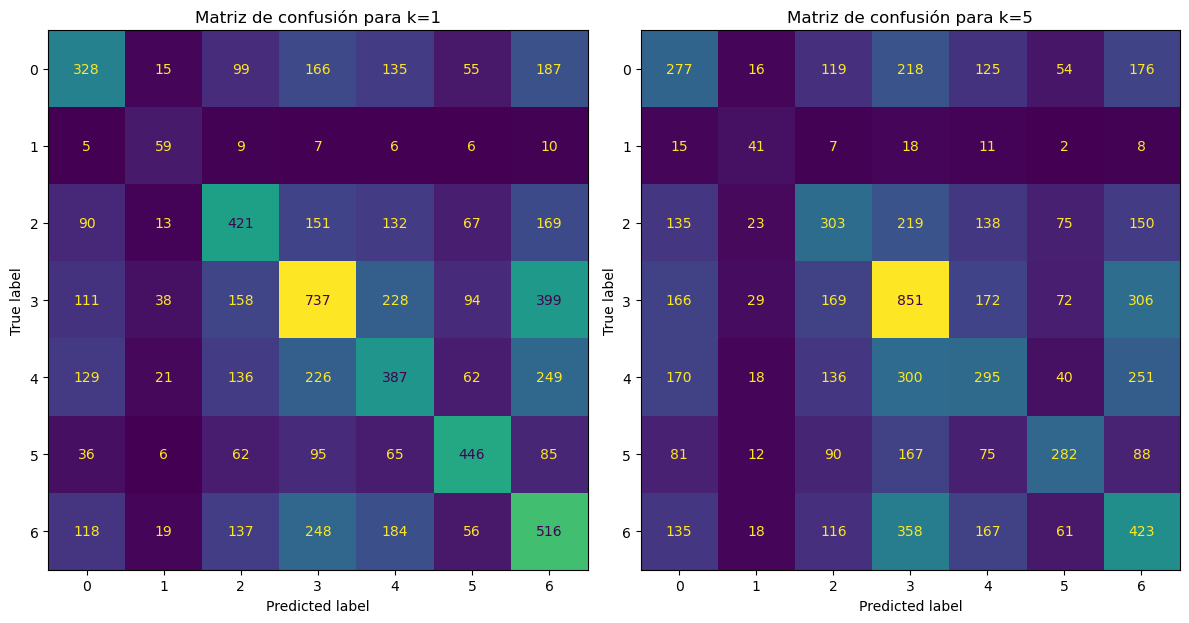

Analiza visualmente las matrices de confusión mostradas para observar las diferencias entre k=1 y k=5.


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Preprocesar el archivo CSV
def preprocess_csv_data(filepath):
    data = pd.read_csv(filepath)
    pixels = data['pixels'].apply(lambda x: np.array(x.split(), dtype='float32').reshape(48, 48))
    X = np.stack(pixels.values) / 255.0  # Normalizar a [0, 1]
    X = X.reshape(len(X), -1)  # Aplanar las imágenes
    y = data['emotion'].values
    return X, y

# Cargar y preprocesar datos
csv_path = './images/fer2013.csv'
X, y = preprocess_csv_data(csv_path)

# Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenar y evaluar KNN para diferentes valores de k
k_values = [1, 5]
conf_matrices = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    conf_matrices.append((k, cm))

# Visualizar matrices de confusión
fig, axes = plt.subplots(1, len(k_values), figsize=(12, 6))
for ax, (k, cm) in zip(axes, conf_matrices):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y))
    disp.plot(ax=ax, cmap='viridis', colorbar=False)
    ax.set_title(f'Matriz de confusión para k={k}')

plt.tight_layout()
plt.show()

# Análisis de resultados
print("Analiza visualmente las matrices de confusión mostradas para observar las diferencias entre k=1 y k=5.")

Ver análisis de diferencias

<!-- 

 ¿Cuáles son las principales diferencias que observas entre las matrices de confusión obtenidas con k=1 y k=5? Razona tu respuesta en términos de la variabilidad intra-clase e inter-clase.

En las matrices de confusión para los valores de k=1 y k=5, se observa que la clase "Felicidad" tiene una mejora notable en la precisión con k=5 en comparación con k=1, lo que sugiere que esta clase tiene menos variabilidad intra-clase y se beneficia de considerar más vecinos. Sin embargo, para las otras clases, la precisión tiende a disminuir o permanecer similar al incrementar el valor de k. Esto indica que para las clases "Enfado", "Asco", "Miedo", "Tristeza", "Sorpresa" y "Neutral", la variabilidad intra-clase es alta, y considerar más vecinos introduce más confusión en la clasificación. Por ejemplo, en la clase "Tristeza", se puede ver una disminución en la precisión al aumentar el número de vecinos, lo que implica que las instancias de esta clase están más dispersas en el espacio de características y no se agrupan tan claramente como en el caso de "Felicidad". Esta comparación sugiere que el valor óptimo de k puede variar significativamente entre diferentes clases y que un análisis más profundo podría ayudar a ajustar el valor de k para mejorar el rendimiento general del modelo.

-->


 #### Caracterización de Imágenes con Agrupamiento

<!--

En la práctica anterior, vimos cómo podemos caracterizar imágenes detectando puntos de interés y caracterizándolos mediante un descriptor de bajo nivel. Sin embargo, los descriptores de bajo nivel tienden a tener un rendimiento bastante limitado a media que avanzamos hacia tareas mas complejas de reconocimiento visual. Para dotar de una mayor capacidad de generalización, podemos utilizar el método Visual Bag of Words ([vBoW](https://en.wikipedia.org/wiki/Bag-of-words_model_in_computer_vision)), que aprovecha el clustering para mejorar la caracterización de las imágenes. Primero, se extraen características locales (como SIFT) de un conjunto de imágenes. Luego, se agrupan estas características en un vocabulario visual mediante clustering, típicamente usando K-means. Cada imagen se representa como un histograma de frecuencia de estas palabras visuales, lo que permite transformar una imagen en una representación de alta dimensión basada en la distribución de sus características locales. Este enfoque es efectivo para tareas de clasificación y recuperación de imágenes, ya que captura patrones visuales relevantes sin necesidad de alinear las imágenes o identificar características específicas a priori. -->
